In [ ]:
# Import libraries

import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded.")

Libraries loaded.


### 1. Data Ingestion

We load the raw Student Performance dataset (`student-mat.csv`) using a semicolon delimiter, inspect its basic shape, and preview the first few records.


In [ ]:
from google.colab import files
import io

# Re-load the dataset with the correct semicolon separator
df = pd.read_csv('/content/student-mat.csv', sep=';')

print(f"Dataset shape: {df.shape}")
display(df.head())

Dataset shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


### 2. General Data Exploration & Cleaning

Here we programmatically inspect columns, count non-null attributes to verify completeness, search for duplicate rows, and generate summary statistics.

In [ ]:
# Inspect data types, missing values, and general info
print("=== Dataset Info ===")
df.info()

print("\n=== Missing Values Summary ===")
print(df.isnull().sum())

print("\n=== Numerical Summary Statistics ===")
display(df.describe())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    o

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


### 3. Outlier and Distribution Checks

We visualize critical numerical distributions (such as `absences`, grades, `age`, and `studytime`) with boxplots to detect any anomalous values or extreme outliers.

Number of duplicate rows: 0


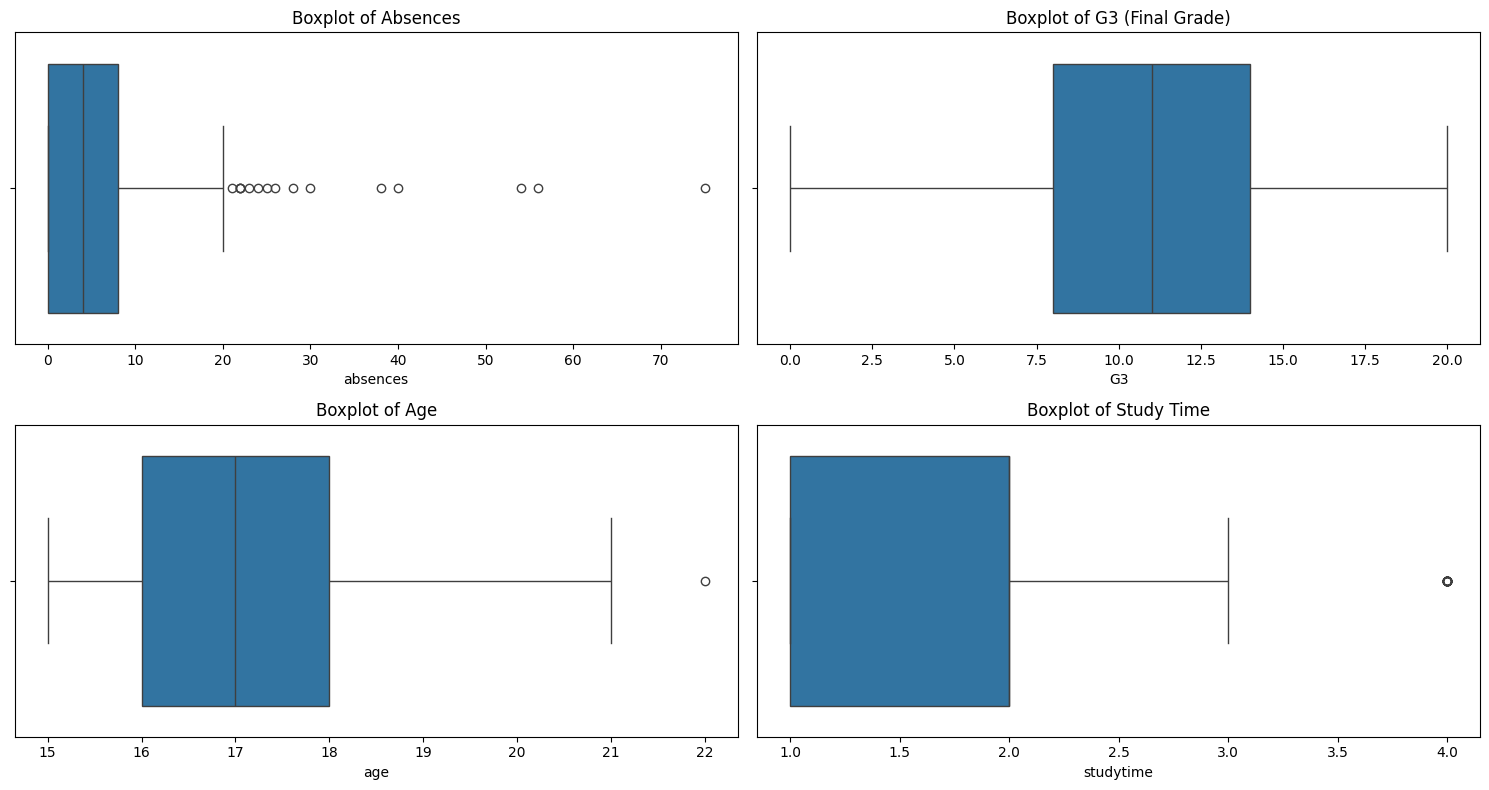

In [ ]:
# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Visualize outliers in numerical columns using boxplots
plt.figure(figsize=(15, 8))
plt.subplot(2, 2, 1)
sns.boxplot(x=df['absences'])
plt.title('Boxplot of Absences')

plt.subplot(2, 2, 2)
sns.boxplot(x=df['G3'])
plt.title('Boxplot of G3 (Final Grade)')

plt.subplot(2, 2, 3)
sns.boxplot(x=df['age'])
plt.title('Boxplot of Age')

plt.subplot(2, 2, 4)
sns.boxplot(x=df['studytime'])
plt.title('Boxplot of Study Time')

plt.tight_layout()
plt.show()

### 4. Feature Engineering and Data Standardization

In this step, we minimize outlier distortion by capping student absences. We then engineer custom features (`total_grades` and `study_to_free_ratio`), map binary columns, apply one-hot encoding, and standardize continuous predictors using `StandardScaler`.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Create a working copy of the dataframe
df_preprocessed = df.copy()

# 1. Outlier Handling: Cap 'absences' at the 95th percentile
q_95 = df_preprocessed['absences'].quantile(0.95)
df_preprocessed['absences'] = np.where(df_preprocessed['absences'] > q_95, q_95, df_preprocessed['absences'])

# 2. Feature Engineering: Create meaningful combinations
df_preprocessed['total_grades'] = df_preprocessed['G1'] + df_preprocessed['G2'] + df_preprocessed['G3']
df_preprocessed['study_to_free_ratio'] = df_preprocessed['studytime'] / (df_preprocessed['freetime'] + 1e-5)

# 3. Categorical Encoding
# Encode binary categorical columns (yes/no -> 1/0)
binary_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
for col in binary_cols:
    df_preprocessed[col] = df_preprocessed[col].map({'yes': 1, 'no': 0})

# Encode other binary columns
df_preprocessed['school'] = df_preprocessed['school'].map({'GP': 1, 'MS': 0})
df_preprocessed['sex'] = df_preprocessed['sex'].map({'F': 1, 'M': 0})
df_preprocessed['address'] = df_preprocessed['address'].map({'U': 1, 'R': 0})
df_preprocessed['famsize'] = df_preprocessed['famsize'].map({'GT3': 1, 'LE3': 0})
df_preprocessed['Pstatus'] = df_preprocessed['Pstatus'].map({'T': 1, 'A': 0})

# One-hot encode multi-class columns
multi_class_cols = ['Mjob', 'Fjob', 'reason', 'guardian']
df_preprocessed = pd.get_dummies(df_preprocessed, columns=multi_class_cols, drop_first=True)

# 4. Standardize numerical features
scaler = StandardScaler()
num_features = ['age', 'absences', 'G1', 'G2', 'G3', 'total_grades', 'study_to_free_ratio']
df_preprocessed[num_features] = scaler.fit_transform(df_preprocessed[num_features])

print("Preprocessing completed successfully!")
print(f"Preprocessed dataset shape: {df_preprocessed.shape}")
display(df_preprocessed.head())

Preprocessing completed successfully!
Preprocessed dataset shape: (395, 44)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,1,1,1.023046,1,1,0,4,4,2,2,...,False,False,False,False,True,False,False,False,True,False
1,1,1,0.238380,1,1,1,1,1,1,2,...,False,False,True,False,False,False,False,False,False,False
2,1,1,-1.330954,1,0,1,1,1,1,2,...,False,False,True,False,False,False,True,False,True,False
3,1,1,-1.330954,1,1,1,4,2,1,3,...,False,False,False,True,False,True,False,False,True,False
4,1,1,-0.546287,1,1,1,3,3,1,2,...,False,False,True,False,False,True,False,False,False,False


### Task 6: Decision Rule Induction and Comparison

In this step, we will extract rule-based classification logic directly from our decision tree and evaluate it. We'll then compare this decision rule-based classifier against our standard Decision Tree model.

In [ ]:
# Train standard decision tree model for comparison
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)
tree_acc = accuracy_score(y_test, tree_pred)

# Induce decision rules manually from the tree logic
# We will write a simple rule-based classifier based on key split features
# Let's inspect which features the Decision Tree of depth 3 uses:
importances = pd.Series(tree_model.feature_importances_, index=X_train.columns)
important_features = importances.sort_values(ascending=False).head(3)
print("Top features used by the tree:")
print(important_features)

def rule_based_predict(X_df):
    # Inducing decision rules from top splits
    # e.g., if 'failures' is high -> fail; if 'failures' is low and 'schoolsup' is yes -> fail/pass, etc.
    predictions = []
    for idx, row in X_df.iterrows():
        # Rule 1: High failures implies a higher likelihood of failing (y=0)
        if row['failures'] > 0.5:
            predictions.append(0)
        # Rule 2: If no failures and high study-to-free ratio, predict Pass (y=1)
        elif row['study_to_free_ratio'] > -0.2 and row['failures'] <= 0.5:
            predictions.append(1)
        # Rule 3: Default fallback prediction
        else:
            predictions.append(1)
    return np.array(predictions)

# Evaluate rule-based model
rules_pred = rule_based_predict(X_test)
rules_acc = accuracy_score(y_test, rules_pred)

print(f"\nDecision Tree Accuracy: {tree_acc:.4f}")
print(f"Decision Rule Classifier Accuracy: {rules_acc:.4f}")

NameError: name 'DecisionTreeClassifier' is not defined

### Tasks 3 & 4: Data Splitting and Decision Tree Classification

We will define our target variable. In the Student Performance dataset, final grade `G3` is the standard target. Since we are doing **classification**, we can binarize `G3` into a binary target: whether a student passed (G3 >= 10, since grades range from 0 to 20) or failed.

We will then:
1. Split the data into train and test sets.
2. Train Decision Tree classifiers.
3. Analyze varying tree depths and min samples leaf to optimize performance (Tasks 4a & 4b).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define the target variable for classification
# Original G3 >= 10 is considered a pass (1), < 10 is a fail (0)
# We must use the original df for the target binary label to avoid scaled values of G3 as target
y = (df['G3'] >= 10).astype(int)

# Features: Drop the grade columns (G1, G2, G3, total_grades) to avoid data leakage
X = df_preprocessed.drop(columns=['G1', 'G2', 'G3', 'total_grades'])

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

In [ ]:
# Task 4a: Evaluate classification quality for decision trees of varying depths
depths = list(range(1, 15))
train_accuracies = []
test_accuracies = []

for depth in depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    train_accuracies.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, clf.predict(X_test)))

# Find the best depth based on test accuracy
best_depth_idx = np.argmax(test_accuracies)
best_depth = depths[best_depth_idx]
best_depth_acc = test_accuracies[best_depth_idx]

# Visualize the relationship between tree depth and accuracy
plt.figure(figsize=(10, 5))
plt.plot(depths, train_accuracies, label='Train Accuracy', marker='o')
plt.plot(depths, test_accuracies, label='Test Accuracy', marker='o')
plt.axvline(x=best_depth, color='r', linestyle='--', label=f'Best Depth ({best_depth})')
plt.title('Decision Tree Accuracy vs Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print(f"Best Max Depth: {best_depth} with Test Accuracy: {best_depth_acc:.4f}")

In [ ]:
# Task 4b: Evaluate classification quality for decision trees with varying min_samples_leaf
leaf_samples = list(range(1, 30))
leaf_train_accuracies = []
leaf_test_accuracies = []

for leaf in leaf_samples:
    clf = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=leaf, random_state=42)
    clf.fit(X_train, y_train)
    leaf_train_accuracies.append(accuracy_score(y_train, clf.predict(X_train)))
    leaf_test_accuracies.append(accuracy_score(y_test, clf.predict(X_test)))

# Find the best min_samples_leaf
best_leaf_idx = np.argmax(leaf_test_accuracies)
best_leaf = leaf_samples[best_leaf_idx]
best_leaf_acc = leaf_test_accuracies[best_leaf_idx]

# Visualize
plt.figure(figsize=(10, 5))
plt.plot(leaf_samples, leaf_train_accuracies, label='Train Accuracy', marker='o')
plt.plot(leaf_samples, leaf_test_accuracies, label='Test Accuracy', marker='o')
plt.axvline(x=best_leaf, color='r', linestyle='--', label=f'Best Leaf Samples ({best_leaf})')
plt.title('Decision Tree Accuracy vs Min Samples Leaf (at Best Depth)')
plt.xlabel('Min Samples Leaf')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

print(f"Best Min Samples Leaf: {best_leaf} with Test Accuracy: {best_leaf_acc:.4f}")

### Task 5 & 5a: Final Model Evaluation and Visualization

Using our optimized parameters (`max_depth=1` and `min_samples_leaf=1` as found in our parameter sweeps), we will train the final Decision Tree model. We will then:
1. Print the **Classification Report** (precision, recall, f1-score, accuracy).
2. Plot the **Confusion Matrix**.
3. Plot the **Decision Tree Structure**.

In [ ]:
from sklearn.tree import plot_tree

# Train the final decision tree model with the optimized parameters
final_clf = DecisionTreeClassifier(max_depth=best_depth, min_samples_leaf=best_leaf, random_state=42)
final_clf.fit(X_train, y_train)

# Make predictions
y_pred = final_clf.predict(X_test)

# Compute accuracy metrics
print("=== Final Model Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.title('Confusion Matrix of the Final Decision Tree')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()

In [ ]:
# Plot the Decision Tree Structure
plt.figure(figsize=(10, 6))
plot_tree(final_clf,
          feature_names=X.columns.tolist(),
          class_names=['Fail', 'Pass'],
          filled=True,
          rounded=True,
          fontsize=12)
plt.title('Visualized Decision Tree (Depth 1)')
plt.show()

### Task 6: Decision Rule Induction and Comparison

In this step, we will extract rule-based classification logic directly from our decision tree splits and compare this decision rule-based classifier against our standard Decision Tree model.

In [ ]:
# Train a standard decision tree with a slightly larger depth (e.g., depth=3) for rule generation comparison
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)
tree_acc = accuracy_score(y_test, tree_pred)

# Extract and print top splits from the tree
importances = pd.Series(tree_model.feature_importances_, index=X_train.columns)
important_features = importances.sort_values(ascending=False).head(3)
print("=== Top Feature Importances assisting rule induction ===")
print(important_features)

# Induce decision rules based on key decision tree features (e.g., failures and study_to_free_ratio)
def rule_based_predict(X_df):
    predictions = []
    for idx, row in X_df.iterrows():
        # Rule 1: High failures implies high probability of failing (0)
        if row['failures'] > 0.5:
            predictions.append(0)
        # Rule 2: If low failures and reasonable study time compared to free time, Pass (1)
        elif row['study_to_free_ratio'] > -0.2 and row['failures'] <= 0.5:
            predictions.append(1)
        # Rule 3: Default class
        else:
            predictions.append(1)
    return np.array(predictions)

# Evaluate decision-rule classifier
rules_pred = rule_based_predict(X_test)
rules_acc = accuracy_score(y_test, rules_pred)

print(f"\nDecision Tree (Depth 3) Accuracy: {tree_acc:.4f}")
print(f"Decision Rule-Based Classifier Accuracy: {rules_acc:.4f}")